# 00 — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

props = pd.read_csv('properties.csv')
cities = pd.read_csv('cities.csv')

print('properties.csv:', props.shape)
print('cities.csv:', cities.shape)

properties.csv: (203874, 26)
cities.csv: (2155, 11)


## Structure & Missing Values

In [2]:
print(props.dtypes)
print()
missing = props.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

ad_title                   str
ad_description             str
details                    str
slug                       str
title                      str
type                       str
price                      str
timestamp                  str
posted_date                str
deactivation_date          str
category                   str
parent_category            str
location                   str
geo_region                 str
area                       str
is_delivery_free          bool
is_doorstep_delivery      bool
is_dsd_applicable         bool
is_member               object
is_authorized_dealer    object
is_featured_member      object
is_verified               bool
membership_level           str
member_since               str
properties                 str
user                       str
dtype: object

member_since            26459
is_featured_member       4462
is_authorized_dealer     4462
is_member                4462
price                    1562
details                  1527

## Listing Type Breakdown

type
for_sale    168971
for_rent     33376
to_rent        837
to_buy         690
Name: count, dtype: int64


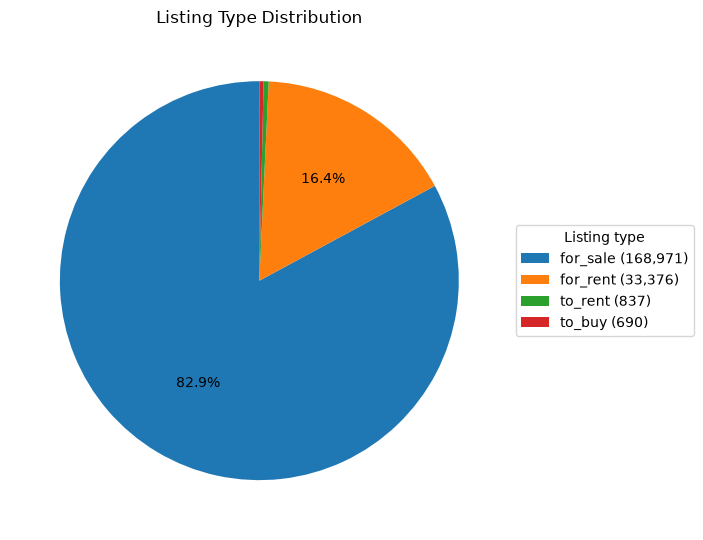

In [3]:
print(props['type'].value_counts())

type_counts = props['type'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5.5))
type_counts.plot(
    kind='pie', labels=None, startangle=90, ax=ax,
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 1 else ''
)
ax.set_title('Listing Type Distribution')
ax.set_ylabel('')
ax.legend(
    [f'{label} ({count:,})' for label, count in type_counts.items()],
    title='Listing type', loc='center left', bbox_to_anchor=(1.0, 0.5)
)
fig.tight_layout()
fig.savefig('eda_type_split.png', dpi=300, bbox_inches='tight')
plt.show()

## Category Breakdown

category
Land For Sale                     82324
Houses For Sale                   52193
Land                              27155
House Rentals                     15179
Apartment Rentals                  7221
Apartments For Sale                5198
Room & Annex Rentals               4609
Commercial Property Rentals        4541
Commercial Properties For Sale     2752
Holiday & Short-Term Rental        2533
Land Rentals                        134
New Projects                         35
Name: count, dtype: int64


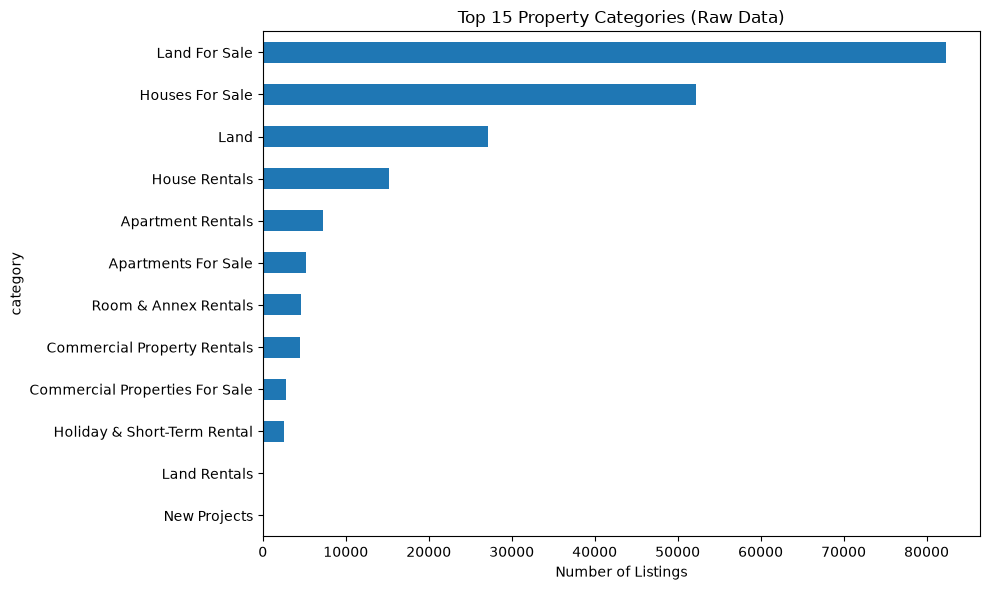

Apartment-category listings: 12419 / 203874 (6.1%)


In [4]:
top_categories = props['category'].value_counts().head(15)
print(top_categories)

plt.figure(figsize=(10,6))
top_categories.sort_values().plot(kind='barh')
plt.xlabel('Number of Listings')
plt.title('Top 15 Property Categories (Raw Data)')
plt.tight_layout()
plt.savefig('eda_category_breakdown.png')
plt.show()

apt_count = props['category'].str.contains('Apartment', case=False, na=False).sum()
print(f'Apartment-category listings: {apt_count} / {len(props)} ({apt_count/len(props)*100:.1f}%)')

## Raw Price Field (Before Cleaning)

In [5]:
print(props['price'].head(10).tolist())

print()
print('Raw price text mixes total sale prices, per-perch land prices, and /month rentals')
print('in one free-text column -- this is why price cleaning and category filtering')
print('(Section 3 of the main pipeline) are needed before any numeric analysis.')

['Rs 59,500,000', 'Rs 50,000 per perch', 'Rs 1,600,000 per perch', 'Rs 1,700,000 per perch', 'Rs 55,000,000', 'Rs 2,600,000 total price', 'Rs 4,700,000 total price', 'Rs 16,000,000 total price', 'Rs 700,000 /month', 'Rs 80,000,000']

Raw price text mixes total sale prices, per-perch land prices, and /month rentals
in one free-text column -- this is why price cleaning and category filtering
(Section 3 of the main pipeline) are needed before any numeric analysis.


## Geographic Coverage

Unique locations in raw data: 204
Unique geo_region codes: 21


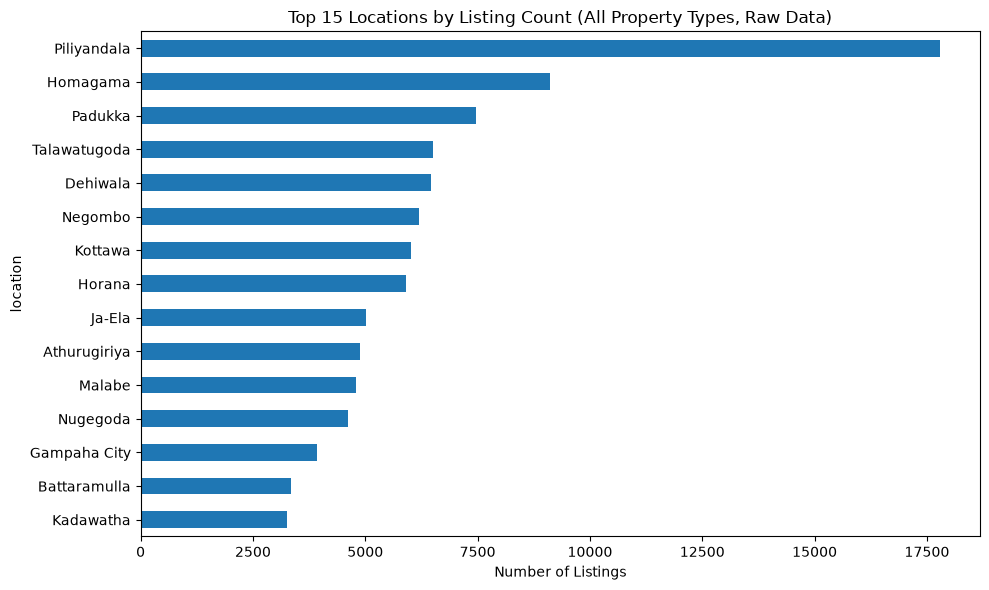

In [6]:
print(f'Unique locations in raw data: {props["location"].nunique()}')
print(f'Unique geo_region codes: {props["geo_region"].nunique()}')

top_locations = props['location'].value_counts().head(15)
plt.figure(figsize=(10,6))
top_locations.sort_values().plot(kind='barh')
plt.xlabel('Number of Listings')
plt.title('Top 15 Locations by Listing Count (All Property Types, Raw Data)')
plt.tight_layout()
plt.savefig('eda_top_locations.png')
plt.show()

## Date Coverage

Earliest posted_date: 2022-09-07 05:58:51+00:00
Latest posted_date: 2023-04-01 21:35:59+00:00


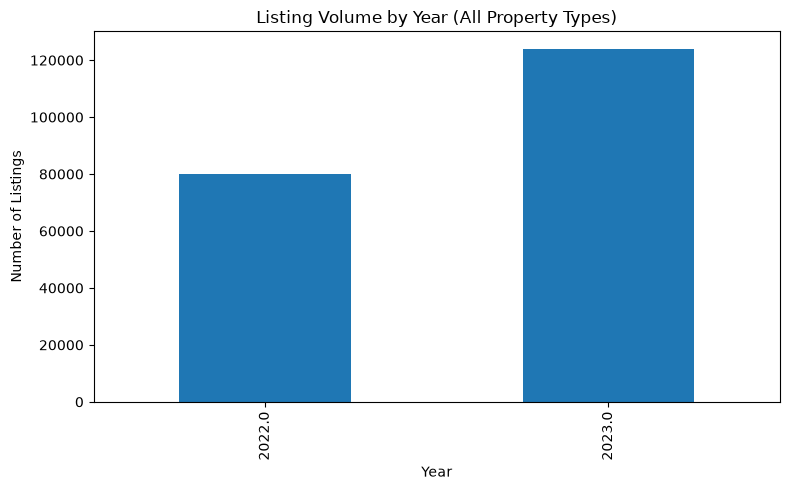

In [7]:
dates = pd.to_datetime(props['posted_date'], errors='coerce', utc=True)
print(f'Earliest posted_date: {dates.min()}')
print(f'Latest posted_date: {dates.max()}')

plt.figure(figsize=(8,5))
dates.dt.year.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Listings')
plt.title('Listing Volume by Year (All Property Types)')
plt.tight_layout()
plt.savefig('eda_year_coverage.png')
plt.show()

## Cities Reference Data

In [8]:
print(cities.columns.tolist())
print(f'Total cities in reference file: {len(cities)}')
print(f'Cities with a postal code: {cities["postcode"].notna().sum()}')
print(f'Cities with coordinates: {cities["latitude"].notna().sum()}')
print(f'Districts represented: {cities["district_id"].nunique()}')

['city id', 'district_id', 'name_en', 'name_si', 'name_ta', 'sub_name_en', 'sub_name_si', 'sub_name_ta', 'postcode', 'latitude', 'longitude']
Total cities in reference file: 2155
Cities with a postal code: 2054
Cities with coordinates: 2155
Districts represented: 25
